# P2 — Credit Risk Scoring

## 01 — Data Preparation

This project is designed to build a **credit risk scoring model** using historical Lending Club loan data.

The objective is to estimate the probability that a loan will default (*Charged Off*) at origination.

- **Unit of observation:** a single issued loan
- **Target:** binary default indicator
- **Population:** loans with a known outcome: `Fully Paid` or `Charged Off`
- **Modeling principle:** use only variables available at loan origination to avoid data leakage

> This project is a credit risk modeling demonstration. It is not intended for use as a production credit-decision model.


In [9]:
# ============================================================
# 1. IMPORTS AND GLOBAL CONFIGURATION
# ============================================================

# Standard library
from pathlib import Path
import gc
import warnings

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# Display and visualization settings
# ------------------------------------------------------------

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep"
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (10, 5)


# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

def find_project_root(start_path: Path) -> Path:
    """
    Traverses parent directories until it finds the project root,
    identified by the pyproject.toml file.
    """
    current_path = start_path.resolve()

    for candidate_path in [current_path, *current_path.parents]:
        if (candidate_path / "pyproject.toml").exists():
            return candidate_path

    raise FileNotFoundError(
        "Project root not found: pyproject.toml is missing."
    )


PROJECT_DIR = find_project_root(Path.cwd())

DATA_RAW_DIR = PROJECT_DIR / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_FIGURES_DIR = OUTPUT_DIR / "figures"
OUTPUT_TABLES_DIR = OUTPUT_DIR / "tables"
OUTPUT_MODELS_DIR = OUTPUT_DIR / "models"

RAW_FILE = DATA_RAW_DIR / "lending_club_accepted_raw.csv"


# Create the required directories defensively
for directory in [
    DATA_PROCESSED_DIR,
    OUTPUT_FIGURES_DIR,
    OUTPUT_TABLES_DIR,
    OUTPUT_MODELS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Startup checks
# ------------------------------------------------------------

assert RAW_FILE.exists(), (
    f"Source file not found: {RAW_FILE}"
)

print(f"Project root: {PROJECT_DIR}")
print(f"Source file: {RAW_FILE.name}")
print(f"Source file size: {RAW_FILE.stat().st_size / 1024**3:.2f} GB")


Project root: /Users/kwamekristianlaban/Documents/Projet_perso/P2
Source file: lending_club_accepted_raw.csv
Source file size: 1.56 GB


## Source File Inspection

The Lending Club file contains historical information on accepted loans. Before applying any transformations, we review its structure, variable types, and a sample of the data.

Because the file is large, the initial exploration is performed without loading the full dataset into memory.


In [10]:
# ============================================================
# 2. SOURCE FILE INSPECTION
# ============================================================

# Read the header only: no data rows are loaded.
raw_columns = pd.read_csv(
    RAW_FILE,
    nrows=0,
    low_memory=False
).columns.tolist()

print(f"Number of columns: {len(raw_columns)}")

print("\nFirst columns:")
print(raw_columns[:25])

print("\nLast columns:")
print(raw_columns[-25:])


Number of columns: 151

First columns:
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti']

Last columns:
['sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog', 'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status', 'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 'hardship_loan_status', 'orig_projected_additional_accrued_interest', 'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 'disbursement_method', 'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status', 'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term']


In [11]:
# Read a very limited sample to understand the raw data formats.
raw_sample = pd.read_csv(
    RAW_FILE,
    nrows=5,
    low_memory=False
)

display(raw_sample)


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,"3,600.0000","3,600.0000","3,600.0000",36 months,13.9900,123.0300,C,C4,leadman,10+ years,MORTGAGE,"55,000.0000",Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.9100,0.0000,Aug-2003,675.0000,679.0000,1.0000,30.0000,NaN,7.0000,0.0000,"2,765.0000",29.7000,13.0000,w,0.0000,0.0000,"4,421.7239","4,421.7200","3,600.0000",821.7200,0.0000,0.0000,0.0000,Jan-2019,122.6700,NaN,Mar-2019,564.0000,560.0000,0.0000,30.0000,1.0000,Individual,NaN,NaN,NaN,0.0000,722.0000,"144,904.0000",2.0000,2.0000,0.0000,1.0000,21.0000,"4,981.0000",36.0000,3.0000,3.0000,722.0000,34.0000,"9,300.0000",3.0000,1.0000,4.0000,4.0000,"20,701.0000","1,506.0000",37.2000,0.0000,0.0000,148.0000,128.0000,3.0000,3.0000,1.0000,4.0000,69.0000,4.0000,69.0000,2.0000,2.0000,4.0000,2.0000,5.0000,3.0000,4.0000,9.0000,4.0000,7.0000,0.0000,0.0000,0.0000,3.0000,76.9000,0.0000,0.0000,0.0000,"178,050.0000","7,746.0000","2,400.0000","13,734.0000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,"24,700.0000","24,700.0000","24,700.0000",36 months,11.9900,820.2800,C,C1,Engineer,10+ years,MORTGAGE,"65,000.0000",Not Verified,Dec-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.0600,1.0000,Dec-1999,715.0000,719.0000,4.0000,6.0000,NaN,22.0000,0.0000,"21,470.0000",19.2000,38.0000,w,0.0000,0.0000,"25,679.6600","25,679.6600","24,700.0000",979.6600,0.0000

## Initial Review

The dataset includes a broad range of variables describing loan amounts, borrower characteristics, credit history, and events occurring after loan origination.

Not every variable is suitable for a probability of default (PD) model:

- Repayment amounts, recoveries, payment dates, and credit scores updated after origination are excluded because they would introduce data leakage.

The final feature set will therefore be restricted to information available when the lending decision is made.


In [12]:
# Critical variables

critical_columns = [
    "id",
    "issue_d",
    "loan_status",
    "term",
    "loan_amnt",
    "int_rate",
    "grade",
    "annual_inc",
    "dti",
    "fico_range_low",
    "fico_range_high",
]

critical_columns_check = pd.DataFrame(
    {
        "column": critical_columns,
        "available": [
            column in raw_columns
            for column in critical_columns
        ],
    }
)

display(critical_columns_check)

assert critical_columns_check["available"].all(), (
    "Some critical columns are missing from the source file."
)


,column,available
0,id,True
1,issue_d,True
2,loan_status,True
3,term,True
4,loan_amnt,True
5,int_rate,True
6,grade,True
7,annual_inc,True
8,dti,True
9,fico_range_low,True


## Critical Variable Validation

All variables required for the analysis are available in the source dataset.

- `loan_status` is used to construct the default target.
- `issue_d` is used to create a time-based data split.
- `term` is used to assess cohort maturity.
- `loan_amnt`, `annual_inc`, `dti`, and FICO score bounds are used to characterize borrower risk at origination.
- `int_rate` and `grade` are retained for exploratory analysis but excluded from the main PD model because they may already reflect Lending Club’s risk assessment.

The dataset therefore provides the information required to begin developing a probability of default model without relying on post-origination variables.


## Key Variables and Data Dictionary

The Lending Club dataset contains information on loan characteristics, borrower profiles, and credit history. To develop a probability of default (PD) model, the analysis must be limited to information known before or at loan origination.

| Variable | Description | Role in the PD Model |
|---|---|---|
| `id` | Unique loan identifier | Used for duplicate checks and traceability; never used as a predictor |
| `issue_d` | Loan issue month and year | Used for time-based splitting, vintage analysis, and drift monitoring |
| `loan_status` | Loan status observed at data extraction | Used to construct the target: `Fully Paid` = 0 and `Charged Off` = 1 |
| `loan_amnt` | Requested or funded loan amount | Represents exposure and may reflect financing needs |
| `term` | Contractual loan term: 36 or 60 months | Used as a risk feature and for cohort-maturity checks |
| `annual_inc` | Borrower’s self-reported annual income | Proxy for repayment capacity; requires outlier treatment |
| `dti` | Monthly debt-to-income ratio | Measures the borrower’s relative debt burden |
| `fico_range_low`, `fico_range_high` | FICO score bounds at origination | Combined into an average FICO score; key indicator of credit quality |
| `emp_length` | Self-reported employment tenure | Proxy for employment stability; requires cleaning |
| `home_ownership` | Housing status: renter, owner, mortgage, etc. | Proxy for residential and financial stability |
| `purpose` | Stated purpose of the loan application | Supports segmentation by financing need, such as consolidation, purchase, or small business |
| `verification_status` | Income-verification status | Indicates the reliability of borrower-reported income information |
| `inq_last_6mths` | Number of credit inquiries during the previous six months | Indicator of recent credit-seeking activity |
| `delinq_2yrs` | Number of delinquencies during the previous two years | Captures recent repayment difficulties |
| `revol_util` | Percentage of revolving credit currently used | Measures pressure on existing revolving credit lines |
| `open_acc`, `total_acc` | Number of open accounts and total accounts | Describe the depth and maturity of the borrower’s credit profile |
| `int_rate` | Interest rate assigned by Lending Club | Available at origination, but excluded from the main PD model because it already reflects a risk decision |
| `grade`, `sub_grade` | Internal Lending Club risk grades | Excluded from the main PD model because they embed the lender’s proprietary risk assessment |
| `total_pymnt`, `recoveries`, `last_pymnt_d`, `out_prncp` | Payments, recoveries, last payment date, and outstanding principal | Prohibited post-origination variables and potential sources of data leakage |


## Business Interpretation

- **Core predictors:** repayment capacity (`annual_inc`, `dti`), credit quality (`fico_score`), payment incidents, revolving-credit utilization, stability (`emp_length`, housing status), and financing need (`loan_amnt`, `purpose`).
- **Variables requiring caution:** `int_rate`, `grade`, and `sub_grade` reflect Lending Club’s own underwriting decision and may therefore capture information that is too close to the target.
- **Excluded variables:** post-origination payments, recoveries, and outstanding-principal measures are removed to prevent data leakage.
- **Modeling implication:** the final PD model should rely on pre-origination borrower and loan characteristics only.


## Loan Status Distribution

The `loan_status` variable indicates the observed status of each loan in the Lending Club extract.

Before defining the target, we measure the distribution of these statuses across the full source file. Only loans with a known final outcome will be retained for default modeling; current or delinquent loans will be excluded because their future status remains uncertain.


In [13]:
# ============================================================
# 4. LOAN STATUS DISTRIBUTION
# ============================================================

TARGET_COLUMN = "loan_status"
CHUNK_SIZE = 200_000

status_counts = pd.Series(dtype="int64")

for chunk in pd.read_csv(
    RAW_FILE,
    usecols=[TARGET_COLUMN],
    chunksize=CHUNK_SIZE,
    low_memory=False,
):
    chunk_counts = chunk[TARGET_COLUMN].value_counts(dropna=False)

    status_counts = status_counts.add(
        chunk_counts,
        fill_value=0,
    )

    del chunk, chunk_counts
    gc.collect()

status_summary = (
    status_counts
    .sort_values(ascending=False)
    .rename_axis("loan_status")
    .reset_index(name="n_loans")
)

status_summary["share"] = (
    status_summary["n_loans"]
    / status_summary["n_loans"].sum()
)

status_summary["share"] = status_summary["share"].astype(float)
status_summary["n_loans"] = status_summary["n_loans"].astype("int64")

display(status_summary)


,loan_status,n_loans,share
0,Fully Paid,1076751,0.4763
1,Current,878317,0.3885
2,Charged Off,268559,0.1188
3,Late (31-120 days),21467,0.0095
4,In Grace Period,8436,0.0037
5,Late (16-30 days),4349,0.0019
6,Does not meet the credit policy. Status:Fully ...,1988,0.0009
7,Does not meet the credit policy. Status:Charge...,761,0.0003
8,Default,40,0.0000
9,NaN,33,0.0000


## Target Definition

The target includes only loans with a known final outcome:

- `Fully Paid` loans are classified as non-defaults: `default_flag = 0`
- `Charged Off` and `Default` loans are classified as defaults: `default_flag = 1`

Current loans, late loans, loans in a grace period, and other statuses without a final outcome are excluded. This ensures that the model learns from loans whose repayment outcome is known.


In [6]:
# Target construction rule
GOOD_STATUSES = ["Fully Paid"]
BAD_STATUSES = ["Charged Off", "Default"]

MATURE_STATUSES = GOOD_STATUSES + BAD_STATUSES

status_summary["target_treatment"] = np.select(
    [
        status_summary["loan_status"].isin(GOOD_STATUSES),
        status_summary["loan_status"].isin(BAD_STATUSES),
    ],
    [
        "Non-default: default_flag = 0",
        "Default: default_flag = 1",
    ],
    default="Exclude: final outcome unknown"
)

display(
    status_summary[
        [
            "loan_status",
            "n_loans",
            "share",
            "target_treatment",
        ]
    ]
)


,loan_status,n_loans,share,target_treatment
0,Fully Paid,1076751,0.4763,Non-defaut : default_flag = 0
1,Current,878317,0.3885,Exclude: final outcome unknown
2,Charged Off,268559,0.1188,Defaut : default_flag = 1
3,Late (31-120 days),21467,0.0095,Exclude: final outcome unknown
4,In Grace Period,8436,0.0037,Exclude: final outcome unknown
5,Late (16-30 days),4349,0.0019,Exclude: final outcome unknown
6,Does not meet the credit policy. Status:Fully ...,1988,0.0009,Exclude: final outcome unknown
7,Does not meet the credit policy. Status:Charge...,761,0.0003,Exclude: final outcome unknown
8,Default,40,0.0000,Defaut : default_flag = 1
9,NaN,33,0.0000,Exclude: final outcome unknown


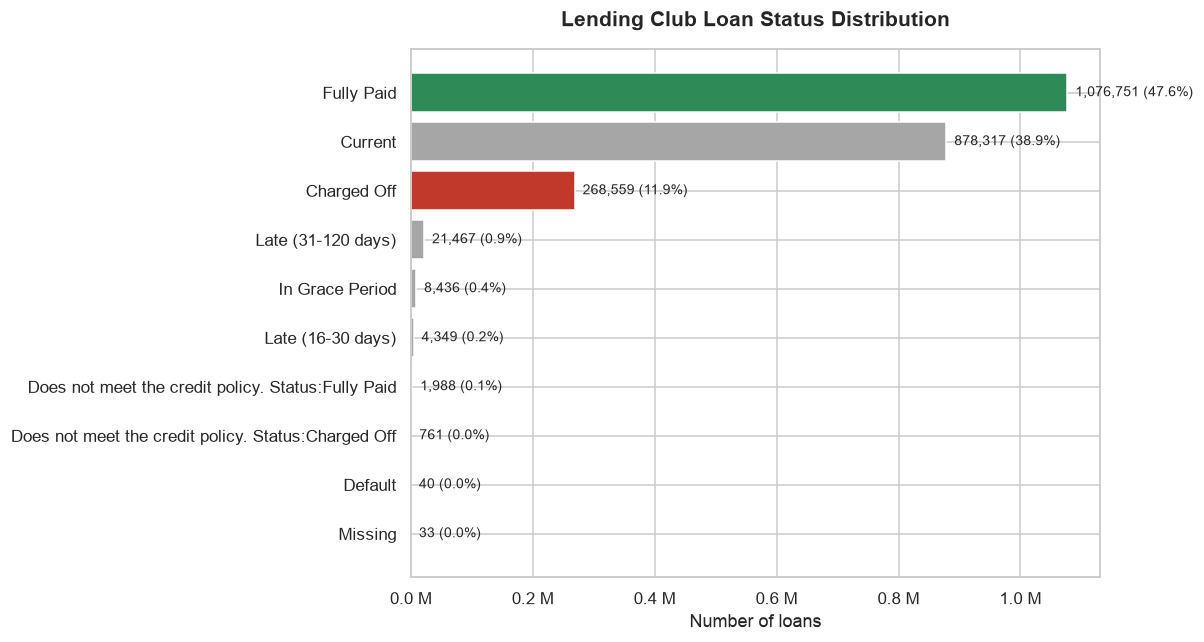

Exported figure : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/loan_status_distribution.png


In [14]:
status_plot_df = status_summary.copy()

status_plot_df["status_label"] = (
    status_plot_df["loan_status"]
    .fillna("Missing")
    .astype(str)
)

status_plot_df = status_plot_df.sort_values(
    "n_loans",
    ascending=True
)

status_colors = np.where(
    status_plot_df["loan_status"].isin(GOOD_STATUSES),
    "#2E8B57",
    np.where(
        status_plot_df["loan_status"].isin(BAD_STATUSES),
        "#C0392B",
        "#A6A6A6"
    )
)

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    status_plot_df["status_label"],
    status_plot_df["n_loans"],
    color=status_colors
)

for bar, (_, row) in zip(bars, status_plot_df.iterrows()):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {row['n_loans']:,} ({row['share']:.1%})",
        va="center",
        fontsize=9
    )

ax.set_title(
    "Lending Club Loan Status Distribution",
    fontsize=14,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Number of loans")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value / 1_000_000:.1f} M")
)

plt.tight_layout()

figure_path = OUTPUT_FIGURES_DIR / "loan_status_distribution.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Exported figure : {figure_path}")


### Interpretation

`Fully Paid` and `Charged Off` loans represent the two main groups with known final outcomes. They will form the training population for the probability of default (PD) model.

Loans with a `Current`, `Late`, or `In Grace Period` status are excluded because their final outcome is unknown at the time of data extraction. Classifying them as non-defaults would artificially understate credit risk and bias the model.

The binary target is defined in the following step:

- `Fully Paid`: `default_flag = 0`
- `Charged Off` or `Default`: `default_flag = 1`



In [15]:
status_summary.to_csv(
    OUTPUT_TABLES_DIR / "loan_status_distribution.csv",
    index=False
)

print(
    "Exported table : "
    f"{OUTPUT_TABLES_DIR / 'loan_status_distribution.csv'}"
)


Exported table : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/loan_status_distribution.csv


### Interpretation

The file contains 1,345,350 loans with a known final outcome:

- 1,076,751 loans were fully repaid.
- 268,599 loans defaulted.

The modelling population has an observed default rate of approximately 20%. Although the target is imbalanced, defaults remain sufficiently represented to train and evaluate a robust probability of default (PD) model.

Loans with a `Current`, `Late`, or `In Grace Period` status are excluded because their final outcome is unknown. Treating them as non-defaults would understate credit risk and introduce maturity bias.


## Building the Analytical Table

We build a dedicated table for probability of default modelling.

Only loans with a known final outcome are retained, and the target is encoded as a binary default flag:

- `Fully Paid`  -> `default_flag = 0`
- `Charged Off` -> `default_flag = 1`

This step ensures that the modelling table is consistent, reproducible, and free from ambiguous outcomes.


In [16]:
# ============================================================
# 5. ANALYTICAL TABLE CONSTRUCTION
# ============================================================

# ID, Date and target
IDENTIFIER_COLUMNS = ["id"]
DATE_COLUMNS = ["issue_d"]
TARGET_COLUMNS = ["loan_status"]

# Contractual Characteristics Known at Origination
LOAN_FEATURES = [
    "loan_amnt",
    "term",
    "purpose",
    "application_type",
]

# Reported Socioeconomic Status
BORROWER_FEATURES = [
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "dti",
    "addr_state",
]

# Credit history available at the time of approval
CREDIT_FEATURES = [
    "earliest_cr_line",
    "fico_range_low",
    "fico_range_high",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "acc_now_delinq",
    "acc_open_past_24mths",
    "bc_open_to_buy",
    "bc_util",
    "chargeoff_within_12_mths",
    "collections_12_mths_ex_med",
    "mort_acc",
    "mths_since_recent_bc",
    "mths_since_recent_inq",
    "num_accts_ever_120_pd",
    "num_tl_30dpd",
    "num_tl_90g_dpd_24m",
    "percent_bc_gt_75",
    "pub_rec_bankruptcies",
    "tax_liens",
    "tot_cur_bal",
    "total_bc_limit",
    "total_rev_hi_lim",
]

# Variables deliberately excluded from the main model:
# - int_rate, grade, and sub_grade: outputs of Lending Club’s risk policy;
# - paiements, recouvrements et soldes : informations post-octroi.
EXCLUDED_POLICY_COLUMNS = [
    "int_rate",
    "grade",
    "sub_grade",
]

MODELING_COLUMNS = (
    IDENTIFIER_COLUMNS
    + DATE_COLUMNS
    + TARGET_COLUMNS
    + LOAN_FEATURES
    + BORROWER_FEATURES
    + CREDIT_FEATURES
)

# Validate against the file header read in the previous section
missing_modeling_columns = sorted(
    set(MODELING_COLUMNS) - set(raw_columns)
)

assert not missing_modeling_columns, (
    "Expected columns missing: "
    f"{missing_modeling_columns}"
)

print(f"Number of columns read: {len(MODELING_COLUMNS)}")
print(f"Predictor variables   : {len(MODELING_COLUMNS) - 3}")
print(f"Excluded variables    : {EXCLUDED_POLICY_COLUMNS}")


Number of columns read: 41
Predictor variables   : 38
Excluded variables    : ['int_rate', 'grade', 'sub_grade']


In [17]:
# Chunked data loading
mature_chunks = []

rows_read = 0
rows_kept = 0

for chunk_number, chunk in enumerate(
    pd.read_csv(
        RAW_FILE,
        usecols=MODELING_COLUMNS,
        chunksize=CHUNK_SIZE,
        low_memory=False
    ),
    start=1
):
    rows_read += len(chunk)

    # Retain only loans with a known final outcome
    mature_chunk = chunk.loc[
        chunk["loan_status"].isin(MATURE_STATUSES)
    ].copy()

    # Création de la cible de défaut
    mature_chunk["default_flag"] = (
        mature_chunk["loan_status"]
        .isin(BAD_STATUSES)
        .astype("int8")
    )

    rows_kept += len(mature_chunk)
    mature_chunks.append(mature_chunk)

    print(
        f"Chunk {chunk_number:02d} | "
        f"lines read : {rows_read:>10,} | "
        f"approved loans : {rows_kept:>10,}"
    )

    del chunk, mature_chunk
    gc.collect()

modeling_df = pd.concat(mature_chunks, ignore_index=True)

del mature_chunks
gc.collect()

print("\n" + "=" * 64)
print("LOADING COMPLETE")
print("=" * 64)
print(f"Raw Loans Read               : {rows_read:,}")
print(f"Loans with known final outcomes retained: {len(modeling_df):,}")
print(f"Share Retained                : {len(modeling_df) / rows_read:.2%}")
print(f"modeling_df dimensions               : {modeling_df.shape}")


Chunk 01 | lines read :    200,000 | approved loans :    176,083
Chunk 02 | lines read :    400,000 | approved loans :    356,181
Chunk 03 | lines read :    600,000 | approved loans :    422,382
Chunk 04 | lines read :    800,000 | approved loans :    508,120
Chunk 05 | lines read :  1,000,000 | approved loans :    571,494
Chunk 06 | lines read :  1,200,000 | approved loans :    748,291
Chunk 07 | lines read :  1,400,000 | approved loans :    896,197
Chunk 08 | lines read :  1,600,000 | approved loans :    916,209
Chunk 09 | lines read :  1,800,000 | approved loans :  1,053,648
Chunk 10 | lines read :  2,000,000 | approved loans :  1,229,863
Chunk 11 | lines read :  2,200,000 | approved loans :  1,310,943
Chunk 12 | lines read :  2,260,701 | approved loans :  1,345,350

LOADING COMPLETE
Raw Loans Read               : 2,260,701
Loans with known final outcomes retained: 1,345,350
Share Retained                : 59.51%
modeling_df dimensions               : (1345350, 42)


In [19]:
#Quality Control

# Consistency Checks for the Analytical Table

assert modeling_df["default_flag"].isin([0, 1]).all(), (
    "default_flag must contain only 0 and 1."
)

assert modeling_df["loan_status"].isin(MATURE_STATUSES).all(), (
    "A non-mature status is present in modeling_df."
)

assert modeling_df["id"].notna().all(), (
    "Some loan identifiers are missing."
)

duplicate_loan_ids = modeling_df["id"].duplicated().sum()

print(f"Number of rows       : {len(modeling_df):,}")
print(f"Number of columns    : {modeling_df.shape[1]:,}")
print(f"Duplicate IDs : {duplicate_loan_ids:,}")
print(f"Default rate         : {modeling_df['default_flag'].mean():.2%}")

assert duplicate_loan_ids == 0, (
    "Duplicate loans were detected."
)


Number of rows       : 1,345,350
Number of columns    : 42
Duplicate IDs : 0
Default rate         : 19.96%


In [20]:
# Final target
target_summary = (
    modeling_df
    .groupby(["loan_status", "default_flag"], observed=True)
    .size()
    .reset_index(name="n_loans")
)

target_summary["share"] = (
    target_summary["n_loans"] / target_summary["n_loans"].sum()
)

target_summary["n_loans"] = target_summary["n_loans"].astype("int64")

display(target_summary)


,loan_status,default_flag,n_loans,share
0,Charged Off,1,268559,0.1996
1,Default,1,40,0.0000
2,Fully Paid,0,1076751,0.8004


### Interpretation

The binary target is fully aligned with the business rule defined earlier:

- `Fully Paid` is coded as non-default (`default_flag = 0`)
- `Charged Off` and `Default` are coded as default (`default_flag = 1`)

The resulting target is suitable for supervised learning because every retained observation has a final outcome that is clearly defined.


## Cohort Time Analysis

The `issue_d` date allows us to analyse loans by vintage and later build a strictly chronological train / validation / test split.

This step is important because default risk may vary over time due to changes in underwriting standards, macroeconomic conditions, and portfolio composition.


In [21]:
# ============================================================
# 6. PREPARING THE TIME DIMENSION
# ============================================================

DATE_COLUMN = "issue_d"

# Observed Original Format : "Dec-2015"
modeling_df[DATE_COLUMN] = pd.to_datetime(
    modeling_df[DATE_COLUMN],
    format="%b-%Y",
    errors="coerce"
)

date_quality = pd.DataFrame(
    {
        "metric": [
            "Number of loans",
            "Missing or invalid dates",
            "Share of missing dates",
            "Minimun Date",
            "Maximum Date",
        ],
        "value": [
            f"{len(modeling_df):,}",
            f"{modeling_df[DATE_COLUMN].isna().sum():,}",
            f"{modeling_df[DATE_COLUMN].isna().mean():.2%}",
            modeling_df[DATE_COLUMN].min().strftime("%Y-%m-%d"),
            modeling_df[DATE_COLUMN].max().strftime("%Y-%m-%d"),
        ],
    }
)

display(date_quality)

# A missing date prevents temporal analysis and subsequent splitting.
rows_before_date_filter = len(modeling_df)

modeling_df = modeling_df.dropna(
    subset=[DATE_COLUMN]
).copy()

print(
    "Loans removed due to missing or invalid dates: "
    f"{rows_before_date_filter - len(modeling_df):,}"
)
print(f"Loans remaining after date check : {len(modeling_df):,}")


,metric,value
0,Number of loans,"1,345,350"
1,Missing or invalid dates,0
2,Share of missing dates,0.00%
3,Minimun Date,2007-06-01
4,Maximum Date,2018-12-01


Loans removed due to missing or invalid dates: 0
Loans remaining after date check : 1,345,350


In [22]:
#Vintage Summary Table
modeling_df["issue_year"] = modeling_df[DATE_COLUMN].dt.year

vintage_summary = (
    modeling_df
    .groupby("issue_year", observed=True)
    .agg(
        n_loans=("id", "size"),
        n_defaults=("default_flag", "sum"),
        default_rate=("default_flag", "mean"),
        mean_loan_amount=("loan_amnt", "mean"),
    )
    .reset_index()
)

vintage_summary["share_loans"] = (
    vintage_summary["n_loans"]
    / vintage_summary["n_loans"].sum()
)

display(vintage_summary)

vintage_summary.to_csv(
    OUTPUT_TABLES_DIR / "vintage_summary.csv",
    index=False
)

print(
    " Exported table : "
    f"{OUTPUT_TABLES_DIR / 'vintage_summary.csv'}"
)


,issue_year,n_loans,n_defaults,default_rate,mean_loan_amount,share_loans
0,2007,251,45,0.1793,"8,841.7331",0.0002
1,2008,1562,247,0.1581,"9,212.7241",0.0012
2,2009,4716,594,0.1260,"9,846.5490",0.0035
3,2010,11536,1487,0.1289,"10,586.0957",0.0086
4,2011,21721,3297,0.1518,"12,047.5036",0.0161
5,2012,53367,8644,0.1620,"13,461.7090",0.0397
6,2013,134804,21024,0.1560,"14,707.3752",0.1002
7,2014,223103,41162,0.1845,"14,582.9034",0.1658
8,2015,375546,75804,0.2019,"14,641.6182",0.2791
9,2016,293105,68252,0.2329,"14,467.0395",0.2179


 Exported table : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/vintage_summary.csv


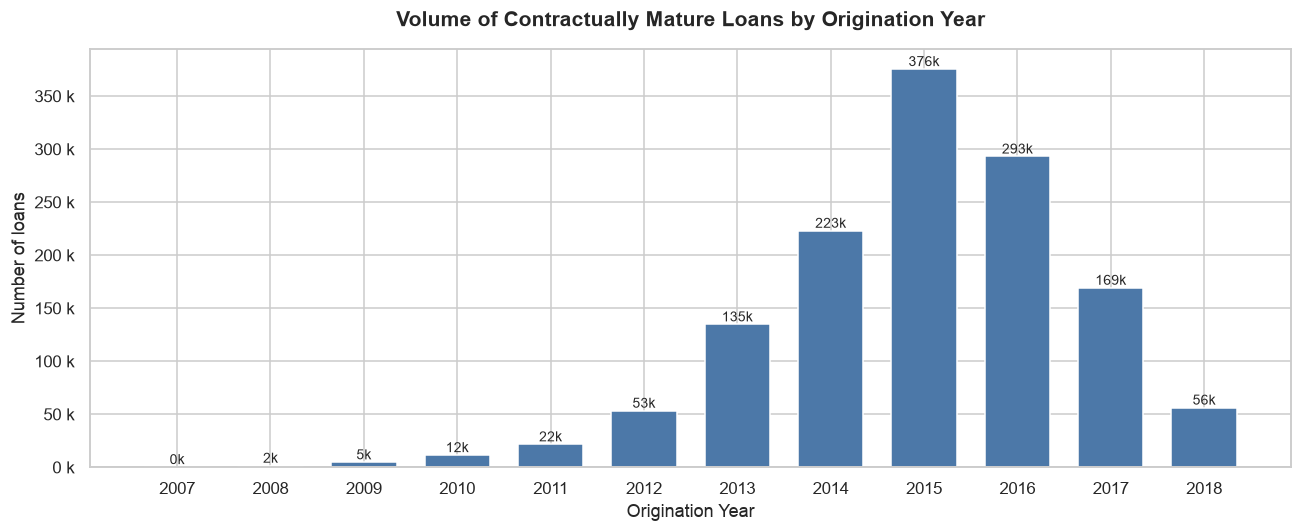

 Exported Figure : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/loan_volume_by_vintage.png


In [23]:
# Chart 1 — Loan Volume by Vintage
# This chart shows the growth or contraction of the Lending Club portfolio and confirms that each future split period contains a sufficient number of loans.

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    vintage_summary["issue_year"].astype(str),
    vintage_summary["n_loans"],
    color="#4C78A8",
    width=0.7
)

for bar, (_, row) in zip(bars, vintage_summary.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{row['n_loans'] / 1_000:.0f}k",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.set_title(
    "Volume of Contractually Mature Loans by Origination Year",
    fontsize=14,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Origination Year")
ax.set_ylabel("Number of loans")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value / 1_000:.0f} k")
)

plt.tight_layout()

figure_path = OUTPUT_FIGURES_DIR / "loan_volume_by_vintage.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f" Exported Figure : {figure_path}")


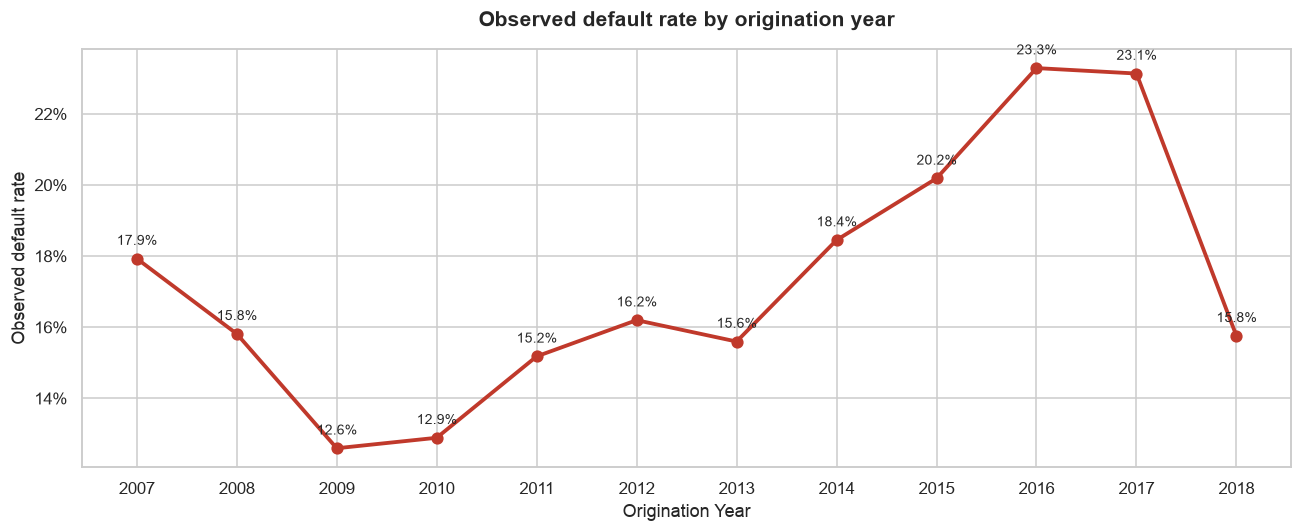

Exported Figure : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/default_rate_by_vintage.png


In [24]:
# Chart 2 — Default rate by vintage
# This chart highlights potential temporal risk drift. If default rates vary substantially across years, a random split would mix different risk environments and be inappropriate.

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    vintage_summary["issue_year"],
    vintage_summary["default_rate"],
    marker="o",
    markersize=7,
    linewidth=2.5,
    color="#C0392B"
)

for _, row in vintage_summary.iterrows():
    ax.annotate(
        f"{row['default_rate']:.1%}",
        (row["issue_year"], row["default_rate"]),
        xytext=(0, 9),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

ax.set_title(
    "Observed default rate by origination year",
    fontsize=14,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Origination Year")
ax.set_ylabel("Observed default rate")
ax.set_xticks(vintage_summary["issue_year"])
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

plt.tight_layout()

figure_path = OUTPUT_FIGURES_DIR / "default_rate_by_vintage.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Exported Figure : {figure_path}")


The analysis confirms strong time drift in the portfolio. The default rate falls to 12.6–12.9% in 2009–2010, then rises to 23.3% in 2016 and 23.1% in 2017; a random split would therefore be misleading.


### Interpretation

The vintages show different volumes and default rates depending on the origination year. This pattern indicates that the portfolio is not perfectly stationary over time and that a random split would fail to reflect future deployment conditions.

A chronological split is therefore more appropriate for evaluating model generalisation.


## Cohort Maturity Diagnostic

Loans with a final status (`Fully Paid` or `Charged Off`) are not necessarily representative of all recently originated loans. Some cohorts are still active and have not yet reached their contractual maturity at the extraction date.

This diagnostic checks whether each vintage can be considered fully observed.


In [25]:
# ============================================================
# 7. COHORT MATURITY DIAGNOSTIC
# ============================================================

OBSERVATION_CUTOFF_DATE = pd.Timestamp("2019-03-31")

# Extract the loan term: " 36 months" becomes 36

modeling_df["term_months"] = (
    modeling_df["term"]
    .str.extract(r"(\d+)", expand=False)
    .astype("Int64")
)

# Theoretical maturity date:
# Origination date + contractual term expressed in months.
modeling_df["contractual_end_date"] = (
    modeling_df[DATE_COLUMN]
    + pd.DateOffset(months=0)  # Initialize a date series.
)

# DateOffset cannot be applied directly to a term that varies by row.
# The conversion to days uses the average length of a month: 365.25 / 12.
modeling_df["contractual_end_date"] = (
    modeling_df[DATE_COLUMN]
    + pd.to_timedelta(
        modeling_df["term_months"].astype(float) * (365.25 / 12),
        unit="D"
    )
)

modeling_df["contractually_mature"] = (
    modeling_df["contractual_end_date"]
    <= OBSERVATION_CUTOFF_DATE
)

maturity_summary = (
    modeling_df
    .groupby(["issue_year", "term_months"], observed=True)
    .agg(
        n_loans=("id", "size"),
        n_contractually_mature=("contractually_mature", "sum"),
        maturity_rate=("contractually_mature", "mean"),
    )
    .reset_index()
    .sort_values(["issue_year", "term_months"])
)

maturity_summary["n_not_mature"] = (
    maturity_summary["n_loans"]
    - maturity_summary["n_contractually_mature"]
)

maturity_summary["term_label"] = (
    maturity_summary["term_months"].astype(str)
    + " months"
)

display(maturity_summary)


,issue_year,term_months,n_loans,n_contractually_mature,maturity_rate,n_not_mature,term_label
0,2007,36,251,251,1.0000,0,36 months
1,2008,36,1562,1562,1.0000,0,36 months
2,2009,36,4716,4716,1.0000,0,36 months
3,2010,36,8466,8466,1.0000,0,36 months
4,2010,60,3070,3070,1.0000,0,60 months
5,2011,36,14101,14101,1.0000,0,36 months
6,2011,60,7620,7620,1.0000,0,60 months
7,2012,36,43470,43470,1.0000,0,36 months
8,2012,60,9897,9897,1.0000,0,60 months
9,2013,36,100422,100422,1.0000,0,36 months


In [27]:
maturity_summary.to_csv(
    OUTPUT_TABLES_DIR / "maturity_by_vintage_and_term.csv",
    index=False
)

print(
    " Exported table : "
    f"{OUTPUT_TABLES_DIR / 'maturity_by_vintage_and_term.csv'}"
)


 Exported table : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/maturity_by_vintage_and_term.csv


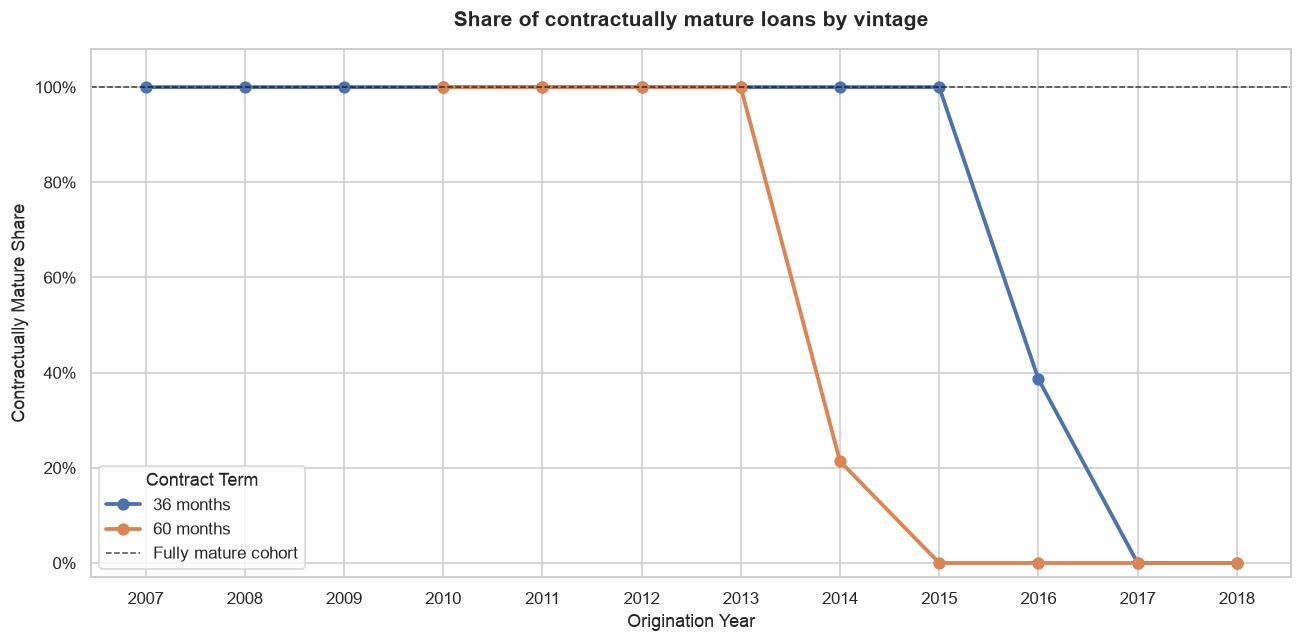

Exported figure : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/maturity_rate_by_vintage_and_term.png


In [28]:
# Chart — Cohort Maturity by Vintage
# A value of 100% means that the entire cohort has theoretically reached the end of its contractual loan term.
# A low value indicates a recent cohort for which final default outcomes are still partially unknown.
# Comparing 36- and 60-month terms clearly shows why longer loans require greater caution.


fig, ax = plt.subplots(figsize=(12, 6))

for term_months, term_data in maturity_summary.groupby(
    "term_months",
    observed=True
):
    ax.plot(
        term_data["issue_year"],
        term_data["maturity_rate"],
        marker="o",
        markersize=7,
        linewidth=2.5,
        label=f"{int(term_months)} months"
    )

ax.axhline(
    y=1.0,
    color="black",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label="Fully mature cohort"
)

ax.set_title(
    "Share of contractually mature loans by vintage",
    fontsize=14,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Origination Year")
ax.set_ylabel("Contractually Mature Share")
ax.set_xticks(sorted(maturity_summary["issue_year"].unique()))
ax.set_ylim(-0.03, 1.08)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

ax.legend(
    title="Contract Term",
    loc="lower left",
    frameon=True
)

plt.tight_layout()

figure_path = (
    OUTPUT_FIGURES_DIR
    / "maturity_rate_by_vintage_and_term.png"
)

plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f"Exported figure : {figure_path}")


### Interpretation

A cohort is considered contractually mature when its full contractual term has elapsed by the extraction date.

Older 36-month vintages are fully observed, while newer 60-month vintages may still be incomplete. This is why maturity must be checked before defining the modelling population.


### Methodological Decision

The diagnostic shows that 36-month loans are fully mature up to the 2015 vintage, while 60-month loans are only fully mature for earlier vintages. To avoid including partially observed loans, the final V1 population will be restricted to 36-month loans originated between 2007 and 2015.


## Final Population and Time Split

The maturity diagnostic confirms that all 36-month loans originated between 2007 and 2015 have reached their contractual horizon by the extraction date.

This subset can therefore be used to define a clean modelling population and to build a chronological split without maturity bias.


In [29]:
# ============================================================
# 8. FINAL POPULATION AND TIME-BASED SPLIT
# ============================================================

FINAL_TERM_MONTHS = 36

TRAIN_END_DATE = pd.Timestamp("2013-12-31")
VALIDATION_END_DATE = pd.Timestamp("2014-12-31")
TEST_END_DATE = pd.Timestamp("2015-12-31")

final_modeling_df = modeling_df.loc[
    (modeling_df["term_months"] == FINAL_TERM_MONTHS)
    & (modeling_df[DATE_COLUMN] <= TEST_END_DATE)
].copy()

print(f"Mature Loans Before Filtering : {len(modeling_df):,}")
print(f"Loans retained for V1     : {len(final_modeling_df):,}")
print(
    "Share of Population Retained : "
    f"{len(final_modeling_df) / len(modeling_df):.2%}"
)

assert final_modeling_df["term_months"].eq(FINAL_TERM_MONTHS).all(), (
    "Error: loans outside the 36-month term were detected."
)

assert final_modeling_df[DATE_COLUMN].le(TEST_END_DATE).all(), (
    "Error: loans originated after December 2015 were detected."

)


Mature Loans Before Filtering : 1,345,350
Loans retained for V1     : 618,584
Share of Population Retained : 45.98%


In [30]:
# Dataset assignment
final_modeling_df["dataset_split"] = np.select(
    [
        final_modeling_df[DATE_COLUMN] <= TRAIN_END_DATE,
        final_modeling_df[DATE_COLUMN] <= VALIDATION_END_DATE,
    ],
    [
        "train",
        "validation",
    ],
    default="test"
)

SPLIT_ORDER = ["train", "validation", "test"]

final_split_summary = (
    final_modeling_df
    .groupby("dataset_split", observed=True)
    .agg(
        start_date=(DATE_COLUMN, "min"),
        end_date=(DATE_COLUMN, "max"),
        n_loans=("id", "size"),
        n_defaults=("default_flag", "sum"),
        default_rate=("default_flag", "mean"),
        mean_loan_amount=("loan_amnt", "mean"),
    )
    .reindex(SPLIT_ORDER)
    .reset_index()
)

final_split_summary["share_loans"] = (
    final_split_summary["n_loans"]
    / final_split_summary["n_loans"].sum()
)

final_split_summary["start_date"] = (
    final_split_summary["start_date"].dt.strftime("%Y-%m")
)

final_split_summary["end_date"] = (
    final_split_summary["end_date"].dt.strftime("%Y-%m")
)

display(final_split_summary)


,dataset_split,start_date,end_date,n_loans,n_defaults,default_rate,mean_loan_amount,share_loans
0,train,2007-06,2013-12,172988,21508,0.1243,"11,902.5983",0.2797
1,validation,2014-01,2014-12,162570,22315,0.1373,"12,585.5985",0.2628
2,test,2015-01,2015-12,283026,42132,0.1489,"12,805.5401",0.4575


In [32]:
# Checks to ensure periods do not overlap

train_max_date = final_modeling_df.loc[
    final_modeling_df["dataset_split"] == "train",
    DATE_COLUMN
].max()

validation_min_date = final_modeling_df.loc[
    final_modeling_df["dataset_split"] == "validation",
    DATE_COLUMN
].min()

validation_max_date = final_modeling_df.loc[
    final_modeling_df["dataset_split"] == "validation",
    DATE_COLUMN
].max()

test_min_date = final_modeling_df.loc[
    final_modeling_df["dataset_split"] == "test",
    DATE_COLUMN
].min()

assert train_max_date <= TRAIN_END_DATE
assert validation_min_date > TRAIN_END_DATE
assert validation_max_date <= VALIDATION_END_DATE
assert test_min_date > VALIDATION_END_DATE
assert final_modeling_df["dataset_split"].isin(SPLIT_ORDER).all()

print("Time-based checks: OK")
print(f"Training end         : {train_max_date:%Y-%m}")
print(f"Validation start  : {validation_min_date:%Y-%m}")
print(f"Validation end    : {validation_max_date:%Y-%m}")
print(f"Test start         : {test_min_date:%Y-%m}")


Time-based checks: OK
Training end         : 2013-12
Validation start  : 2014-01
Validation end    : 2014-12
Test start         : 2015-01


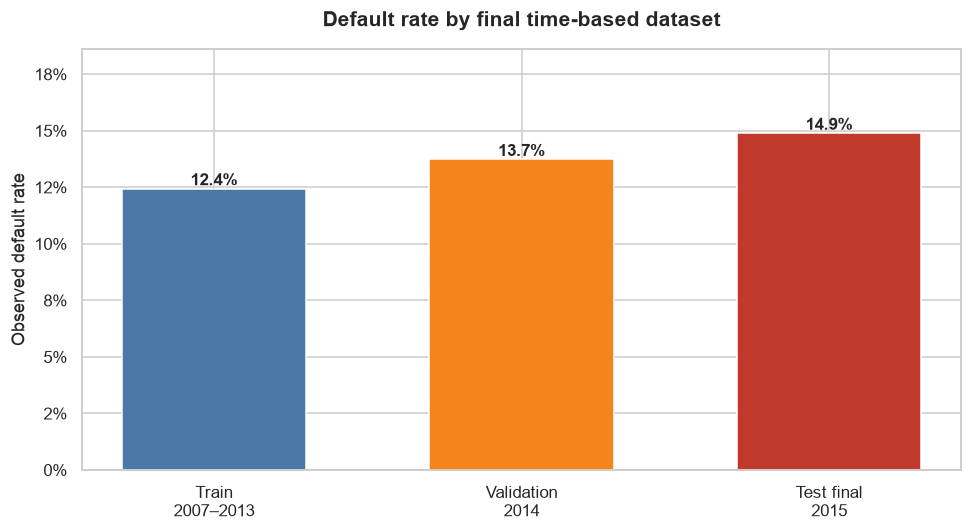

Figure exportée : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/default_rate_by_final_split.png


In [33]:
# Chart — Default rate by dataset
# This chart highlights risk drift across the three periods. It is not a model result, but an important diagnostic: higher default rates in validation or test make evaluation more realistic and demanding.
split_plot_df = final_split_summary.copy()

split_plot_df["dataset_label"] = split_plot_df["dataset_split"].map({
    "train": "Train\n2007–2013",
    "validation": "Validation\n2014",
    "test": "Test final\n2015",
})

split_colors = {
    "train": "#4C78A8",
    "validation": "#F58518",
    "test": "#C0392B",
}

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    split_plot_df["dataset_label"],
    split_plot_df["default_rate"],
    color=[
        split_colors[split_name]
        for split_name in split_plot_df["dataset_split"]
    ],
    width=0.6
)

for bar, (_, row) in zip(bars, split_plot_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{row['default_rate']:.1%}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "Default rate by final time-based dataset",
    fontsize=14,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("")
ax.set_ylabel("Observed default rate")
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)
ax.set_ylim(0, split_plot_df["default_rate"].max() * 1.25)

plt.tight_layout()

figure_path = OUTPUT_FIGURES_DIR / "default_rate_by_final_split.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f" Exported figure : {figure_path}")



The final split is coherent and robust for the next steps: it is strictly chronological, all three samples are large, and the default rate increases gradually from 12.4% to 14.9%. This creates a realistic evaluation of the model’s ability to generalise to a future, riskier portfolio.


In [34]:
final_split_summary.to_csv(
    OUTPUT_TABLES_DIR / "final_temporal_split_summary.csv",
    index=False
)

print(
    "Exported table : "
    f"{OUTPUT_TABLES_DIR / 'final_temporal_split_summary.csv'}"
)


Exported table : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/final_temporal_split_summary.csv


## Variable Quality Check

Before preparing the variables for modelling, we conduct a quality audit on the final population.

The audit checks:

- variable types;
- the presence of missing values;
- basic consistency across fields;
- categorical levels that may require harmonisation or grouping.


In [35]:
# ============================================================
# 9. VARIABLE QUALITY CHECK
# ============================================================

# Variables not used as predictors
METADATA_COLUMNS = [
    "id",
    "issue_d",
    "issue_year",
    "loan_status",
    "default_flag",
    "dataset_split",
    "term_months",
    "contractual_end_date",
    "contractually_mature",
]

# `term` is constant in the final population:
# all retained loans have a 36-month term.
CONSTANT_BY_DESIGN_COLUMNS = [
    "term",
]

FEATURE_COLUMNS = [
    column
    for column in final_modeling_df.columns
    if column not in METADATA_COLUMNS + CONSTANT_BY_DESIGN_COLUMNS
]

NUMERICAL_FEATURES = [
    column
    for column in FEATURE_COLUMNS
    if pd.api.types.is_numeric_dtype(final_modeling_df[column])
]

CATEGORICAL_FEATURES = [
    column
    for column in FEATURE_COLUMNS
    if column not in NUMERICAL_FEATURES
]

print(f"Candidate model variables: {len(FEATURE_COLUMNS)}")
print(f"Numerical variables      : {len(NUMERICAL_FEATURES)}")
print(f"Categorical variables    : {len(CATEGORICAL_FEATURES)}")

print("\nVariables numériques :")
print(NUMERICAL_FEATURES)

print("\nVariables catégorielles :")
print(CATEGORICAL_FEATURES)


Candidate model variables: 37
Numerical variables      : 30
Categorical variables    : 7

Variables numériques :
['loan_amnt', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'total_bc_limit']

Variables catégorielles :
['emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'earliest_cr_line', 'application_type']


In [36]:
quality_overview = pd.DataFrame(
    {
        "variable": FEATURE_COLUMNS,
        "dtype": [
            str(final_modeling_df[column].dtype)
            for column in FEATURE_COLUMNS
        ],
        "n_missing": [
            final_modeling_df[column].isna().sum()
            for column in FEATURE_COLUMNS
        ],
        "missing_rate": [
            final_modeling_df[column].isna().mean()
            for column in FEATURE_COLUMNS
        ],
        "n_unique": [
            final_modeling_df[column].nunique(dropna=True)
            for column in FEATURE_COLUMNS
        ],
    }
)

quality_overview["variable_type"] = np.where(
    quality_overview["variable"].isin(NUMERICAL_FEATURES),
    "Numerical",
    "Categorical"
)

quality_overview = quality_overview.sort_values(
    ["missing_rate", "n_unique"],
    ascending=[False, False]
).reset_index(drop=True)

display(quality_overview)


,variable,dtype,n_missing,missing_rate,n_unique,variable_type
0,mths_since_recent_inq,float64,97955,0.1584,26,Numerical
1,tot_cur_bal,float64,51646,0.0835,258756,Numerical
2,total_rev_hi_lim,float64,51646,0.0835,16414,Numerical
3,num_accts_ever_120_pd,float64,51646,0.0835,35,Numerical
4,num_tl_90g_dpd_24m,float64,51646,0.0835,23,Numerical
5,num_tl_30dpd,float64,51646,0.0835,5,Numerical
6,bc_util,float64,41324,0.0668,1347,Numerical
7,percent_bc_gt_75,float64,41291,0.0668,207,Numerical
8,bc_open_to_buy,float64,40937,0.0662,55357,Numerical
9,mths_since_recent_bc,float64,40526,0.0655,440,Numerical


In [37]:
# Constant columns
constant_columns = quality_overview.loc[
    quality_overview["n_unique"] <= 1,
    "variable"
].tolist()

print(f"Number of constant variables: {len(constant_columns)}")
print("Constant variables:", constant_columns)

assert "term" not in FEATURE_COLUMNS, (
    "`term` must be excluded because it is constant in the final population."
)


Number of constant variables: 0
Constant variables: []


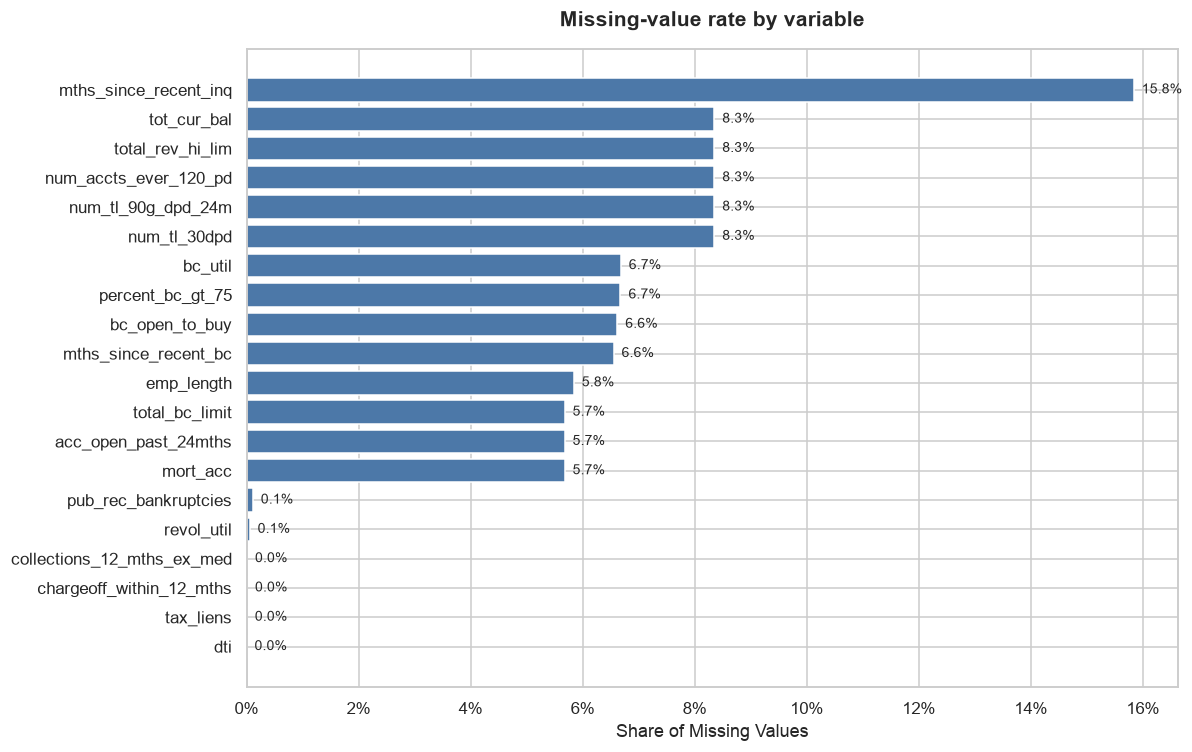

 Exported Figure : /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/figures/missing_rate_by_feature.png


In [38]:
#Chart — missing data
missing_plot_df = (
    quality_overview
    .loc[quality_overview["missing_rate"] > 0]
    .sort_values("missing_rate", ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    missing_plot_df["variable"],
    missing_plot_df["missing_rate"],
    color="#4C78A8"
)

for bar, (_, row) in zip(bars, missing_plot_df.iterrows()):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"  {row['missing_rate']:.1%}",
        va="center",
        fontsize=9
    )

ax.set_title(
    "Missing-value rate by variable",
    fontsize=14,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Share of Missing Values")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)

plt.tight_layout()

figure_path = OUTPUT_FIGURES_DIR / "missing_rate_by_feature.png"
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print(f" Exported Figure : {figure_path}")


In [39]:
#Stability Across Time Periods
# A variable may be well populated in training but nearly absent in testing. This data-drift risk can weaken the model in production.
missing_by_split = (
    final_modeling_df
    .groupby("dataset_split", observed=True)[FEATURE_COLUMNS]
    .apply(lambda dataframe: dataframe.isna().mean())
    .T
    .reindex(columns=SPLIT_ORDER)
    .reset_index(names="variable")
)

missing_by_split["max_missing_rate"] = (
    missing_by_split[SPLIT_ORDER].max(axis=1)
)

missing_by_split["missing_rate_range"] = (
    missing_by_split[SPLIT_ORDER].max(axis=1)
    - missing_by_split[SPLIT_ORDER].min(axis=1)
)

missing_by_split = missing_by_split.sort_values(
    "max_missing_rate",
    ascending=False
).reset_index(drop=True)

display(missing_by_split)


dataset_split,variable,train,validation,test,max_missing_rate,missing_rate_range
0,tot_cur_bal,0.2986,0.0000,0.0000,0.2986,0.2986
1,num_tl_90g_dpd_24m,0.2986,0.0000,0.0000,0.2986,0.2986
2,num_tl_30dpd,0.2986,0.0000,0.0000,0.2986,0.2986
3,num_accts_ever_120_pd,0.2986,0.0000,0.0000,0.2986,0.2986
4,total_rev_hi_lim,0.2986,0.0000,0.0000,0.2986,0.2986
5,mths_since_recent_inq,0.2966,0.0948,0.1104,0.2966,0.2017
6,bc_util,0.2105,0.0116,0.0107,0.2105,0.1998
7,percent_bc_gt_75,0.2101,0.0114,0.0109,0.2101,0.1992
8,bc_open_to_buy,0.2101,0.0108,0.0100,0.2101,0.2001
9,mths_since_recent_bc,0.2092,0.0099,0.0096,0.2092,0.1996


In [31]:
# Descriptive statistics
numerical_summary = (
    final_modeling_df[NUMERICAL_FEATURES]
    .describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    )
    .T
)

numerical_summary["missing_rate"] = (
    final_modeling_df[NUMERICAL_FEATURES]
    .isna()
    .mean()
)

numerical_summary = numerical_summary.sort_index()

display(numerical_summary)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_rate
acc_now_delinq,"618,584.0000",0.0048,0.0767,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,14.0000,0.0000
acc_open_past_24mths,"583,463.0000",4.3564,2.9733,0.0000,0.0000,1.0000,2.0000,4.0000,6.0000,10.0000,14.0000,64.0000,0.0568
annual_inc,"618,584.0000","72,558.7335","66,270.8336",0.0000,"17,000.0000","25,500.0000","43,000.0000","60,000.0000","87,000.0000","150,000.0000","250,000.0000","9,000,000.0000",0.0000
bc_open_to_buy,"577,647.0000","8,970.1064","14,233.9314",0.0000,0.0000,105.0000,"1,176.0000","3,845.0000","10,521.0000","35,497.4000","69,565.0800","497,445.0000",0.0662
bc_util,"577,260.0000",62.7111,27.2228,0.0000,0.1000,12.4000,42.6000,66.6000,86.4000,98.2000,101.0000,339.6000,0.0668
chargeoff_within_12_mths,"618,528.0000",0.0089,0.1081,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,10.0000,0.0001
collections_12_mths_ex_med,"618,528.0000",0.0149,0.1379,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,20.0000,0.0001
delinq_2yrs,"618,584.0000",0.3150,0.8689,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,4.0000,30.0000,0.0000
dti,"618,582.0000",17.5632,8.3843,0.0000,1.8300,4.8400,11.3500,17.0400,23.3300,32.1000,37.0800,999.0000,0.0000
fico_range_high,"618,584.0000",699.1137,31.1489,629.0000,664.0000,664.0000,674.0000,694.0000,714.0000,764.0000,799.0000,850.0000,0.0000


### Interpretation

Variables with missing values will be handled inside the modelling pipelines. For numeric features, imputation will be estimated on the training set and then applied to the validation and test sets.

This approach preserves out-of-sample discipline and prevents information leakage.


In [32]:
quality_overview.to_csv(
    OUTPUT_TABLES_DIR / "feature_quality_overview.csv",
    index=False
)

missing_by_split.to_csv(
    OUTPUT_TABLES_DIR / "missingness_by_temporal_split.csv",
    index=False
)

numerical_summary.to_csv(
    OUTPUT_TABLES_DIR / "numerical_feature_summary.csv"
)

print("Exports Created :")
print("-", OUTPUT_TABLES_DIR / "feature_quality_overview.csv")
print("-", OUTPUT_TABLES_DIR / "missingness_by_temporal_split.csv")
print("-", OUTPUT_TABLES_DIR / "numerical_feature_summary.csv")


Exports créés :
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/feature_quality_overview.csv
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/missingness_by_temporal_split.csv
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/numerical_feature_summary.csv


## Derived Variable Creation

Some raw variables become more useful after transformation:

- the two FICO score bounds are combined into a single score;
- credit-history length and employment length are cleaned and standardised;
- selected categorical variables are prepared for grouping or encoding.

These transformations make the information more stable and easier to model.


In [40]:
# ============================================================
# 10. STABLE DERIVED FEATURE CREATION
# ============================================================

# ------------------------------------------------------------
# Average FICO score
# ------------------------------------------------------------

final_modeling_df["fico_score"] = (
    final_modeling_df["fico_range_low"]
    + final_modeling_df["fico_range_high"]
) / 2


# ------------------------------------------------------------
# Credit History Length
# ------------------------------------------------------------

# Expected format example: "Jan-1998"
final_modeling_df["earliest_cr_line_date"] = pd.to_datetime(
    final_modeling_df["earliest_cr_line"],
    format="%b-%Y",
    errors="coerce"
)

final_modeling_df["credit_history_months"] = (
    (
        final_modeling_df[DATE_COLUMN].dt.year
        - final_modeling_df["earliest_cr_line_date"].dt.year
    ) * 12
    + (
        final_modeling_df[DATE_COLUMN].dt.month
        - final_modeling_df["earliest_cr_line_date"].dt.month
    )
).astype("Float64")


# ------------------------------------------------------------
# Employment Length
# ------------------------------------------------------------

EMP_LENGTH_MAPPING = {
    "< 1 year": 0.5,
    "1 year": 1.0,
    "2 years": 2.0,
    "3 years": 3.0,
    "4 years": 4.0,
    "5 years": 5.0,
    "6 years": 6.0,
    "7 years": 7.0,
    "8 years": 8.0,
    "9 years": 9.0,
    "10+ years": 10.0,
}

final_modeling_df["emp_length_years"] = (
    final_modeling_df["emp_length"]
    .map(EMP_LENGTH_MAPPING)
    .astype("Float64")
)


# ------------------------------------------------------------
# Consistency Checks
# ------------------------------------------------------------

derived_feature_summary = pd.DataFrame(
    {
        "variable": [
            "fico_score",
            "credit_history_months",
            "emp_length_years",
        ],
        "missing_rate": [
            final_modeling_df["fico_score"].isna().mean(),
            final_modeling_df["credit_history_months"].isna().mean(),
            final_modeling_df["emp_length_years"].isna().mean(),
        ],
        "minimum": [
            final_modeling_df["fico_score"].min(),
            final_modeling_df["credit_history_months"].min(),
            final_modeling_df["emp_length_years"].min(),
        ],
        "median": [
            final_modeling_df["fico_score"].median(),
            final_modeling_df["credit_history_months"].median(),
            final_modeling_df["emp_length_years"].median(),
        ],
        "maximum": [
            final_modeling_df["fico_score"].max(),
            final_modeling_df["credit_history_months"].max(),
            final_modeling_df["emp_length_years"].max(),
        ],
    }
)

display(derived_feature_summary)

assert final_modeling_df["fico_score"].between(300, 850).all(), (
    "Some FICO scores fall outside the theoretical range [300, 850]."
)

assert (
    final_modeling_df["credit_history_months"].dropna() >= 0
).all(), (
    "Negative credit-history lengths were detected."
)


,variable,missing_rate,minimum,median,maximum
0,fico_score,0.0000,627.0000,692.0000,847.5000
1,credit_history_months,0.0000,36.0000,175.0000,852.0000
2,emp_length_years,0.0584,0.5000,6.0000,10.0000


### Categorical Level Stability

A categorical level observed only in the validation or test period cannot be learned properly by a model trained on the development sample.

We therefore check the stability of each category across the chronological split and group rare or unstable levels when needed.


In [41]:
# Application type
application_type_by_split = pd.crosstab(
    final_modeling_df["application_type"],
    final_modeling_df["dataset_split"],
    normalize="columns"
).reindex(columns=SPLIT_ORDER, fill_value=0)

application_type_counts = pd.crosstab(
    final_modeling_df["application_type"],
    final_modeling_df["dataset_split"]
).reindex(columns=SPLIT_ORDER, fill_value=0)

application_type_summary = (
    application_type_counts
    .add_suffix("_n")
    .join(application_type_by_split.add_suffix("_share"))
    .reset_index()
)

display(application_type_summary)


dataset_split,application_type,train_n,validation_n,test_n,train_share,validation_share,test_share
0,Individual,172988,162570,282787,1.0000,1.0000,0.9992
1,Joint App,0,0,239,0.0000,0.0000,0.0008


In [35]:
# General audit
CATEGORICAL_AUDIT_COLUMNS = [
    "home_ownership",
    "purpose",
    "verification_status",
    "addr_state",
    "application_type",
]

unseen_categories_records = []

for feature in CATEGORICAL_AUDIT_COLUMNS:
    train_categories = set(
        final_modeling_df.loc[
            final_modeling_df["dataset_split"] == "train",
            feature
        ]
        .fillna("Missing")
        .astype(str)
        .unique()
    )

    for split_name in ["validation", "test"]:
        future_categories = set(
            final_modeling_df.loc[
                final_modeling_df["dataset_split"] == split_name,
                feature
            ]
            .fillna("Missing")
            .astype(str)
            .unique()
        )

        unseen_categories = sorted(
            future_categories - train_categories
        )

        unseen_categories_records.append(
            {
                "variable": feature,
                "dataset_split": split_name,
                "n_unseen_categories": len(unseen_categories),
                "unseen_categories": ", ".join(unseen_categories)
                if unseen_categories
                else "None",
            }
        )

unseen_categories_summary = pd.DataFrame(
    unseen_categories_records
)

display(unseen_categories_summary)


,variable,dataset_split,n_unseen_categories,unseen_categories
0,home_ownership,validation,1,ANY
1,home_ownership,test,1,ANY
2,purpose,validation,0,None
3,purpose,test,0,None
4,verification_status,validation,0,None
5,verification_status,test,0,None
6,addr_state,validation,0,None
7,addr_state,test,1,ND
8,application_type,validation,0,None
9,application_type,test,1,Joint App


In [42]:
# Variables retained for the V1 baseline:
# only variables stable over time, followed by derived variables.

BASE_NUMERICAL_FEATURES = [
    "loan_amnt",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "acc_now_delinq",
    "chargeoff_within_12_mths",
    "collections_12_mths_ex_med",
    "pub_rec_bankruptcies",
    "tax_liens",
    "fico_score",
    "credit_history_months",
    "emp_length_years",
]

BASE_CATEGORICAL_FEATURES = [
    "home_ownership",
    "purpose",
    "verification_status",
    "addr_state",
]

BASE_FEATURES = (
    BASE_NUMERICAL_FEATURES
    + BASE_CATEGORICAL_FEATURES
)

print(f"Retained numerical variables   : {len(BASE_NUMERICAL_FEATURES)}")
print(f"Retained categorical variables: {len(BASE_CATEGORICAL_FEATURES)}")
print(f"Total V1 variables               : {len(BASE_FEATURES)}")

assert all(
    column in final_modeling_df.columns
    for column in BASE_FEATURES
), "A selected variable is missing from final_modeling_df."


Retained numerical variables   : 18
Retained categorical variables: 4
Total V1 variables               : 22


### Interpretation and Decision on Derived Variables

The average FICO score, credit-history length, and employment length are now available in a numeric form that is more suitable for modelling.

The transformation decisions are consistent with credit-risk practice: improve stability, reduce noise, and keep the variables interpretable.


## Final Modelling Sets

The final table contains only the variables retained for V1, the default target, the origination date, and the temporal split label.

The training, validation, and test sets are now ready for downstream modelling tasks.


In [49]:
# Final feature list
# ============================================================
# 11. FREEZE THE FINAL DATASETS AND EXPORT TO PARQUET
# ============================================================

FINAL_NUMERICAL_FEATURES = [
    "loan_amnt",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "acc_now_delinq",
    "chargeoff_within_12_mths",
    "collections_12_mths_ex_med",
    "pub_rec_bankruptcies",
    "tax_liens",
    "fico_score",
    "credit_history_months",
    "emp_length_years",
]

FINAL_CATEGORICAL_FEATURES = [
    "home_ownership",
    "purpose",
    "verification_status",
]

FINAL_FEATURES = (
    FINAL_NUMERICAL_FEATURES
    + FINAL_CATEGORICAL_FEATURES
)

EXPORT_METADATA_COLUMNS = [
    "id",
    "issue_d",
    "dataset_split",
    "default_flag",
]

EXPORT_COLUMNS = (
    EXPORT_METADATA_COLUMNS
    + FINAL_FEATURES
)

assert len(FINAL_FEATURES) == 21, (
    "V1 must contain 21 predictor variables."
)

assert all(
    column in final_modeling_df.columns
    for column in EXPORT_COLUMNS
), "At least one export column is missing."


In [50]:
# A rare mode of transportation that is not available on the train.
# This rule does not depend on any target statistics.
final_modeling_df["home_ownership"] = (
    final_modeling_df["home_ownership"]
    .fillna("Missing")
    .replace(
        {
            "ANY": "OTHER",
            "NONE": "OTHER",
        }
    )
)

# Check: no category in future datasets should be unknown to training.
train_home_ownership = set(
    final_modeling_df.loc[
        final_modeling_df["dataset_split"] == "train",
        "home_ownership"
    ].unique()
)

for split_name in ["validation", "test"]:
    future_home_ownership = set(
        final_modeling_df.loc[
            final_modeling_df["dataset_split"] == split_name,
            "home_ownership"
        ].unique()
    )

    unseen_modalities = future_home_ownership - train_home_ownership

    assert not unseen_modalities, (
        f"Unknown categories in {split_name}: {unseen_modalities}"
    )

print("home_ownership category check: OK")


home_ownership category check: OK


In [51]:
# ------------------------------------------------------------
# Standardize identifiers before Parquet export
# ------------------------------------------------------------

# `id` is a business identifier, never a numeric variable.
# Some rows were read with mixed data types:
# So we cast it to a string.
final_modeling_df["id"] = (
    final_modeling_df["id"]
    .astype("string")
    .str.strip()
)

assert final_modeling_df["id"].notna().all(), (
    "Some loan identifiers are missing."
)

assert final_modeling_df["id"].str.len().gt(0).all(), (
    "Some loan identifiers are empty."
)

print(f"Type de id après conversion : {final_modeling_df['id'].dtype}")
print(
    "Number of unique identifiers: "
    f"{final_modeling_df['id'].nunique():,}"
)


Type de id après conversion : string
Number of unique identifiers: 618,584


In [52]:
# Create the datasets
train_df = (
    final_modeling_df
    .loc[
        final_modeling_df["dataset_split"] == "train",
        EXPORT_COLUMNS
    ]
    .copy()
)

validation_df = (
    final_modeling_df
    .loc[
        final_modeling_df["dataset_split"] == "validation",
        EXPORT_COLUMNS
    ]
    .copy()
)

test_df = (
    final_modeling_df
    .loc[
        final_modeling_df["dataset_split"] == "test",
        EXPORT_COLUMNS
    ]
    .copy()
)

assert len(train_df) + len(validation_df) + len(test_df) == len(
    final_modeling_df
), "The exported datasets do not cover the entire final population."

assert (
    train_df["issue_d"].max()
    < validation_df["issue_d"].min()
    < test_df["issue_d"].min()
), "The time periods overlap."

print(f"Train      : {train_df.shape}")
print(f"Validation : {validation_df.shape}")
print(f"Test       : {test_df.shape}")

Train      : (172988, 25)
Validation : (162570, 25)
Test       : (283026, 25)


In [47]:
#Verification Parquet
try:
    import pyarrow
except ImportError as error:
    raise ImportError(
        "pyarrow is missing from the active kernel. "
        "Check to see if the laptop is using the kernel "
        "'Python 3.11 — “Credit Risk P2,” then restart it."
    ) from error

print(f"Version pyarrow : {pyarrow.__version__}")


Version pyarrow : 25.0.0


In [53]:
TRAIN_FILE = DATA_PROCESSED_DIR / "train_v1.parquet"
VALIDATION_FILE = DATA_PROCESSED_DIR / "validation_v1.parquet"
TEST_FILE = DATA_PROCESSED_DIR / "test_v1.parquet"

train_df.to_parquet(
    TRAIN_FILE,
    index=False,
    engine="pyarrow",
)

validation_df.to_parquet(
    VALIDATION_FILE,
    index=False,
    engine="pyarrow",
)

test_df.to_parquet(
    TEST_FILE,
    index=False,
    engine="pyarrow",
)

print("Exports Parquet créés :")
print(f"- {TRAIN_FILE}")
print(f"- {VALIDATION_FILE}")
print(f"- {TEST_FILE}")


Exports Parquet créés :
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/data/processed/train_v1.parquet
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/data/processed/validation_v1.parquet
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/data/processed/test_v1.parquet


In [54]:
export_check = []

for dataset_name, file_path, expected_df in [
    ("train", TRAIN_FILE, train_df),
    ("validation", VALIDATION_FILE, validation_df),
    ("test", TEST_FILE, test_df),
]:
    reloaded_df = pd.read_parquet(
        file_path,
        engine="pyarrow",
    )

    export_check.append(
        {
            "dataset": dataset_name,
            "file": file_path.name,
            "n_rows_expected": len(expected_df),
            "n_rows_reloaded": len(reloaded_df),
            "n_columns": reloaded_df.shape[1],
            "default_rate": reloaded_df["default_flag"].mean(),
            "file_size_mb": file_path.stat().st_size / 1024**2,
        }
    )

    assert len(reloaded_df) == len(expected_df), (
        f"Incorrect row count after export: {dataset_name}"
    )

    assert list(reloaded_df.columns) == EXPORT_COLUMNS, (
        f"Incorrect columns after export: {dataset_name}"
    )

export_check = pd.DataFrame(export_check)

display(export_check)


,dataset,file,n_rows_expected,n_rows_reloaded,n_columns,default_rate,file_size_mb
0,train,train_v1.parquet,172988,172988,25,0.1243,3.7167
1,validation,validation_v1.parquet,162570,162570,25,0.1373,3.6023
2,test,test_v1.parquet,283026,283026,25,0.1489,6.0428


## Data Preparation Conclusion

The V1 modelling base is now frozen.

It includes only fully mature 36-month loans originated between 2007 and 2015, with a clean temporal split and a target that is fully observed.

This creates a sound foundation for the next stages of the credit risk modelling pipeline.


## Delivery Manifest

This section documents the datasets produced for modelling. The manifest improves reproducibility by preserving the dimensions, periods, and file locations of each exported dataset.


In [55]:
# ============================================================
# 12. DELIVERY MANIFEST AND FINAL CHECKS
# ============================================================

DATASET_FILES = {
    "train": TRAIN_FILE,
    "validation": VALIDATION_FILE,
    "test": TEST_FILE,
}

manifest_records = []

for dataset_name, file_path in DATASET_FILES.items():
    dataset_df = pd.read_parquet(
        file_path,
        engine="pyarrow",
    )

    manifest_records.append(
        {
            "dataset": dataset_name,
            "file_name": file_path.name,
            "n_rows": len(dataset_df),
            "n_columns": dataset_df.shape[1],
            "start_date": dataset_df["issue_d"].min().strftime("%Y-%m"),
            "end_date": dataset_df["issue_d"].max().strftime("%Y-%m"),
            "n_defaults": int(dataset_df["default_flag"].sum()),
            "default_rate": dataset_df["default_flag"].mean(),
            "file_size_mb": file_path.stat().st_size / 1024**2,
        }
    )

delivery_manifest = pd.DataFrame(manifest_records)

display(delivery_manifest)


,dataset,file_name,n_rows,n_columns,start_date,end_date,n_defaults,default_rate,file_size_mb
0,train,train_v1.parquet,172988,25,2007-06,2013-12,21508,0.1243,3.7167
1,validation,validation_v1.parquet,162570,25,2014-01,2014-12,22315,0.1373,3.6023
2,test,test_v1.parquet,283026,25,2015-01,2015-12,42132,0.1489,6.0428


In [56]:
feature_manifest = pd.DataFrame(
    {
        "variable": FINAL_FEATURES,
        "feature_type": (
            ["numerical"] * len(FINAL_NUMERICAL_FEATURES)
            + ["categorical"] * len(FINAL_CATEGORICAL_FEATURES)
        ),
        "used_in_v1": True,
    }
)

display(feature_manifest)


,variable,feature_type,used_in_v1
0,loan_amnt,numerical,True
1,annual_inc,numerical,True
2,dti,numerical,True
3,delinq_2yrs,numerical,True
4,inq_last_6mths,numerical,True
5,open_acc,numerical,True
6,pub_rec,numerical,True
7,revol_bal,numerical,True
8,revol_util,numerical,True
9,total_acc,numerical,True


In [57]:
assert (
    delivery_manifest["n_rows"].sum()
    == len(final_modeling_df)
), "The total number of exported rows does not match the final population."

assert delivery_manifest["n_columns"].eq(
    len(EXPORT_COLUMNS)
).all(), "The number of columns differs across the exported files."

assert (
    train_df["issue_d"].max()
    < validation_df["issue_d"].min()
    < test_df["issue_d"].min()
), "Time overlap detected between datasets."

assert set(FINAL_FEATURES).isdisjoint(
    {
        "id",
        "issue_d",
        "loan_status",
        "default_flag",
        "dataset_split",
    }
), "A metadata column or the target is included among the predictors."

print("Contrôles de livraison : OK")
print(f"V1 variables       : {len(FINAL_FEATURES)}")
print(f"Prêts exportés     : {delivery_manifest['n_rows'].sum():,}")
print(
    "Défauts exportés   : "
    f"{delivery_manifest['n_defaults'].sum():,}"
)


Contrôles de livraison : OK
V1 variables       : 21
Prêts exportés     : 618,584
Défauts exportés   : 85,955


In [58]:
delivery_manifest.to_csv(
    OUTPUT_TABLES_DIR / "data_delivery_manifest_v1.csv",
    index=False,
)

feature_manifest.to_csv(
    OUTPUT_TABLES_DIR / "final_feature_list_v1.csv",
    index=False,
)

print("Manifest exporté :")
print("-", OUTPUT_TABLES_DIR / "data_delivery_manifest_v1.csv")
print("-", OUTPUT_TABLES_DIR / "final_feature_list_v1.csv")


Manifest exporté :
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/data_delivery_manifest_v1.csv
- /Users/kwamekristianlaban/Documents/Projet_perso/P2/outputs/tables/final_feature_list_v1.csv


### Deliverables Produced

Data preparation is complete. The following files are available in `data/processed`:

- `train_v1.parquet`;
- `validation_v1.parquet`;
- `test_v1.parquet`;
- `population_v1.parquet`;
- `manifest_v1.csv`.

These files provide a clean starting point for the subsequent modelling notebooks.
